# 1. Time Series Review
# Plot monthly mean discharge and concentration for two hydrological stations

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA

In [3]:
#Change root to your folder path
root = r'c:\Users\leoni\OneDrive\Documents\Master Umwelting ETH\Semester 2\Labor WRM\Asssignment 2\Assignment 2-20260512\DATA\DATA'
q1 = pd.read_csv(os.path.join(root,'Q_Diepoldsau_m3s.csv'), parse_dates=['timestamp']).set_index('timestamp')
q2 = pd.read_csv(os.path.join(root,'Q_Gisingen_1976-2023.csv'), parse_dates=['timestamp']).set_index('timestamp')
ssc1 = pd.read_csv(os.path.join(root,'SSC_Diepoldsau_gL.csv'), parse_dates=['timestamp']).set_index('timestamp')
ssc2 = pd.read_csv(os.path.join(root,'SSC_Gisingen_2003-2020.csv'), parse_dates=['timestamp']).set_index('timestamp')

In [4]:
q1 = q1.resample('ME').mean()
q2 = q2.resample('ME').mean()
ssc1 = ssc1.resample('ME').mean()
ssc2 = ssc2.resample('ME').mean()

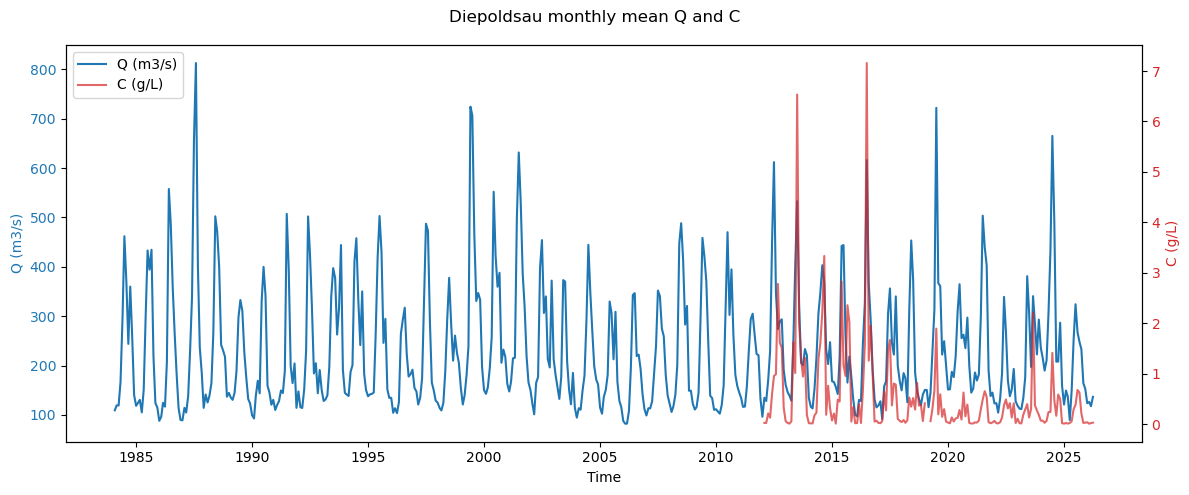

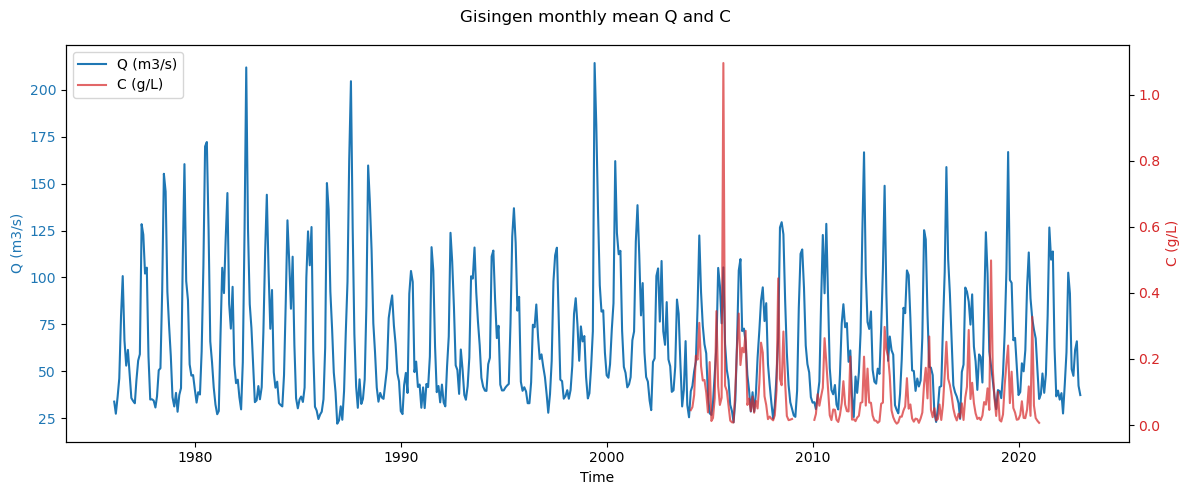

In [5]:
for station, dfQ, dfC in [('Diepoldsau', q1, ssc1), ('Gisingen', q2, ssc2)]:
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(dfQ.index, dfQ['q_m3s'], label='Q (m3/s)', color='tab:blue')
    ax.set_xlabel('Time')
    ax.set_ylabel('Q (m3/s)', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax.twinx()
    ax2.plot(dfC.index, dfC.iloc[:,0], label='C (g/L)', color='tab:red', alpha=0.7)
    ax2.set_ylabel('C (g/L)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc='upper left')
    fig.suptitle(f'{station} monthly mean Q and C')
    fig.tight_layout()
    plt.show()

# 1.2 Stationarity test and trend removal
This section fits a linear trend to each station's monthly mean discharge series, tests the slope significance at the 5% level, removes any statistically significant trend, and verifies that the detrended series has zero mean and finite variance.

In [10]:
station_results = []
detrended_series = {}

for station, dfQ, dfC in [('Diepoldsau', q1, ssc1), ('Gisingen', q2, ssc2)]:
    for var_name, series in [('Q', dfQ['q_m3s']), ('C', dfC.iloc[:, 0])]:
        y = series.dropna()
        x = np.arange(len(y))
        trend = linregress(x, y.values)
        pvalue = trend.pvalue
        slope_sig = pvalue < 0.05
        if slope_sig:
            detrended = y.values - (trend.intercept + trend.slope * x)
            detrend_method = 'linear trend'
        else:
            detrended = y.values - y.values.mean()
            detrend_method = 'mean'
        detrended_mean = detrended.mean()
        detrended_var = detrended.var(ddof=1)
        key = f'{station}_{var_name}'
        detrended_series[key] = pd.Series(detrended, index=y.index)
        station_results.append({
            'station': station,
            'variable': var_name,
            'n_points': len(y),
            'slope': trend.slope,
            'pvalue': pvalue,
            'significant': slope_sig,
            'detrend_method': detrend_method,
            'mean_after_detrend': detrended_mean,
            'variance_after_detrend': detrended_var,
        })
        print(f"{station} {var_name}: n={len(y)}, slope={trend.slope:.6f}, p={pvalue:.4f}, significant={slope_sig}")
        print(f"    detrend method = {detrend_method}")
        print(f"    mean after detrending = {detrended_mean:.6e}")
        print(f"    variance after detrending = {detrended_var:.6e}\n")

station_results_df = pd.DataFrame(station_results)
station_results_df

Diepoldsau Q: n=507, slope=-0.019002, p=0.6136, significant=False
    detrend method = mean
    mean after detrending = -2.421731e-14
    variance after detrending = 1.533543e+04

Diepoldsau C: n=169, slope=-0.006028, p=0.0000, significant=True
    detrend method = linear trend
    mean after detrending = 1.497816e-16
    variance after detrending = 7.961486e-01

Gisingen Q: n=564, slope=-0.007518, p=0.3952, significant=False
    detrend method = mean
    mean after detrending = 7.710145e-15
    variance after detrending = 1.166312e+03

Gisingen C: n=192, slope=-0.000396, p=0.0076, significant=True
    detrend method = linear trend
    mean after detrending = 1.127570e-17
    variance after detrending = 1.265569e-02



,station,variable,n_points,slope,pvalue,significant,detrend_method,mean_after_detrend,variance_after_detrend
0,Diepoldsau,Q,507,-0.019002,0.613569,False,mean,-2.421731e-14,15335.425888
1,Diepoldsau,C,169,-0.006028,0.000033,True,linear trend,1.497816e-16,0.796149
2,Gisingen,Q,564,-0.007518,0.395156,False,mean,7.710145e-15,1166.312366
3,Gisingen,C,192,-0.000396,0.007625,True,linear trend,1.127570e-17,0.012656


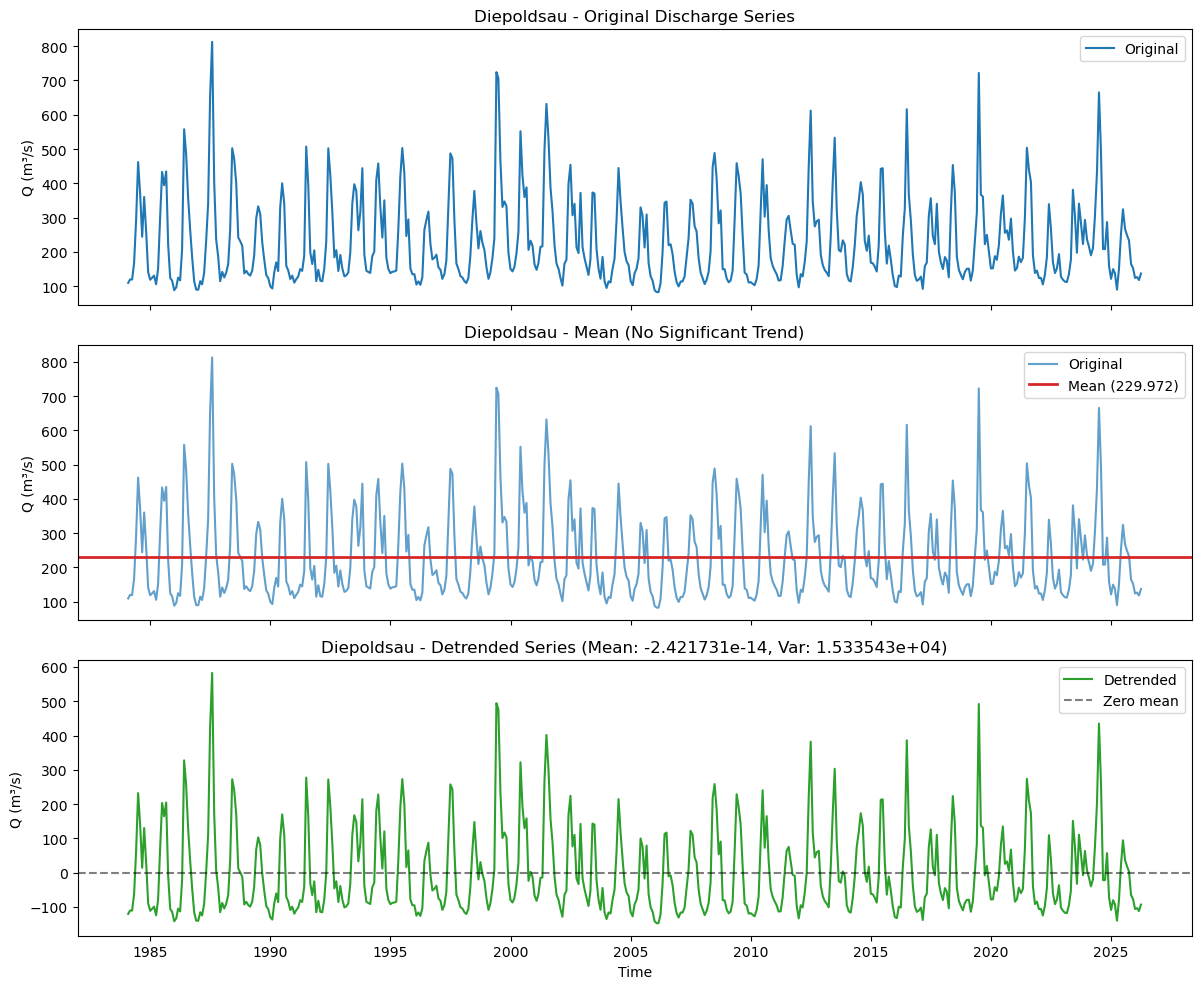

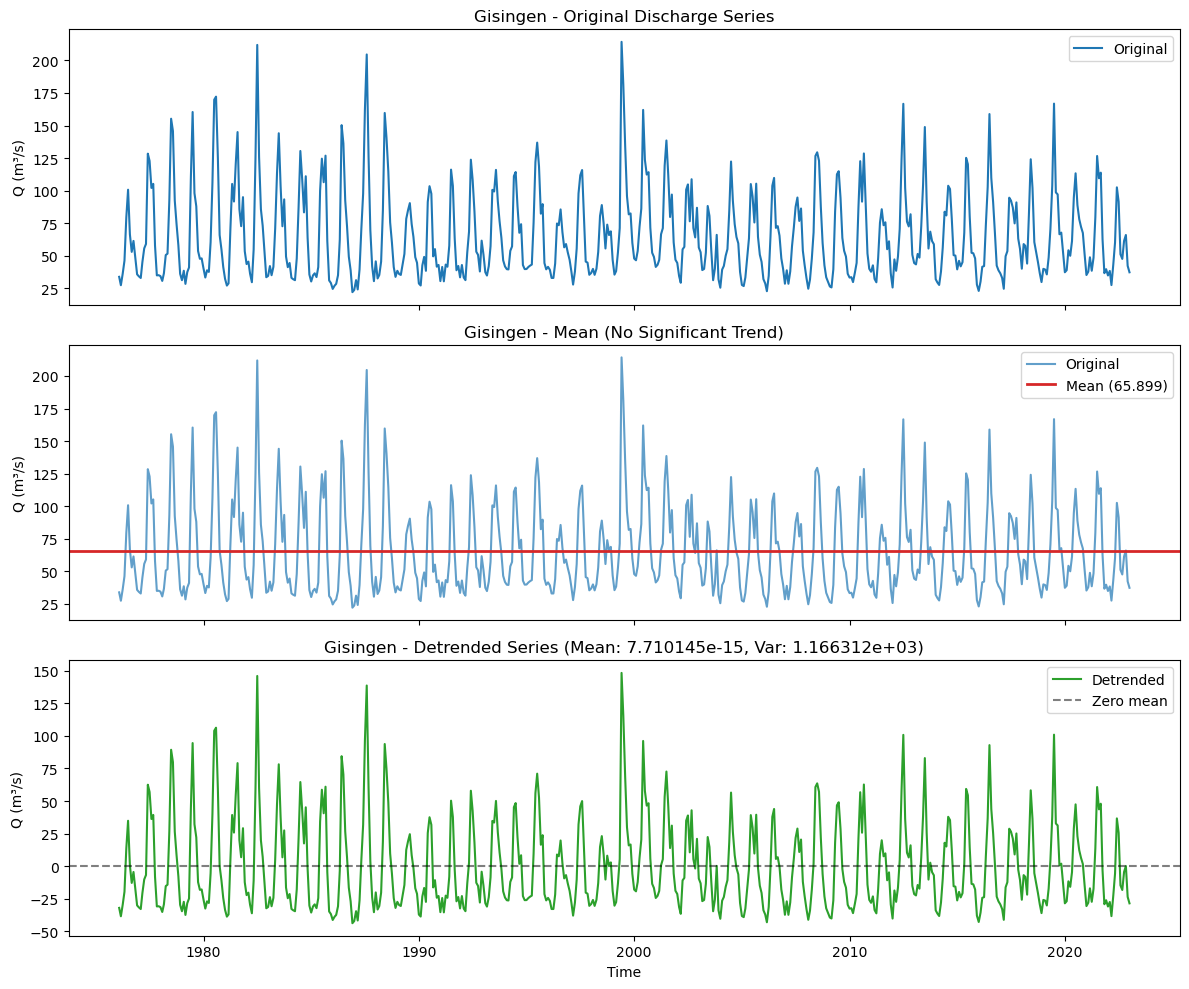

In [7]:
for station, dfQ in [('Diepoldsau', q1), ('Gisingen', q2)]:
    y = dfQ['q_m3s'].dropna()
    x = np.arange(len(y))
    trend = linregress(x, y.values)
    pvalue = trend.pvalue
    slope_sig = pvalue < 0.05
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    
    # Original series
    axes[0].plot(y.index, y.values, label='Original', color='tab:blue')
    axes[0].set_title(f'{station} - Original Discharge Series')
    axes[0].set_ylabel('Q (m³/s)')
    axes[0].legend()
    
    # Trend
    if slope_sig:
        trend_line = trend.intercept + trend.slope * x
        axes[1].plot(y.index, y.values, label='Original', color='tab:blue', alpha=0.7)
        axes[1].plot(y.index, trend_line, label=f'Trend (slope={trend.slope:.6f}, p={pvalue:.4f})', color='tab:red', linewidth=2)
        axes[1].set_title(f'{station} - Linear Trend (Significant)')
    else:
        axes[1].plot(y.index, y.values, label='Original', color='tab:blue', alpha=0.7)
        axes[1].axhline(y=y.values.mean(), label=f'Mean ({y.values.mean():.3f})', color='tab:red', linewidth=2)
        axes[1].set_title(f'{station} - Mean (No Significant Trend)')
    axes[1].set_ylabel('Q (m³/s)')
    axes[1].legend()
    
    # Detrended series
    detrended = detrended_series[station]
    axes[2].plot(detrended.index, detrended.values, label='Detrended', color='tab:green')
    axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero mean')
    axes[2].set_title(f'{station} - Detrended Series (Mean: {detrended.mean():.6e}, Var: {detrended.var(ddof=1):.6e})')
    axes[2].set_ylabel('Q (m³/s)')
    axes[2].set_xlabel('Time')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

## Comment on Statistical Trend in Discharge Data

The statistical analysis performed on the discharge data for both Diepoldsau and Gisingen stations revealed no significant linear trend (p-values > 0.05 for both stations). This lack of a significant trend suggests that the observed variations in discharge are primarily due to natural variability, seasonal fluctuations, or short-term weather events rather than a systematic measuring error or an underlying physical process such as long-term climate change, land use changes, or catchment alterations.

Measuring errors, if present, would typically manifest as systematic biases (e.g., consistent over- or under-estimation) that could potentially create spurious trends, but the statistical tests indicate no such trend exists. The detrended series (by subtracting the mean) show zero-centered fluctuations, confirming stationarity for time series modeling purposes.

However, it's important to note that:
- The time series cover different periods (Diepoldsau: ~42 years, Gisingen: ~47 years), which may not be sufficient to detect very gradual changes.
- Hydrological trends can be non-linear or influenced by external factors not captured in this analysis.
- Further investigation with additional environmental data (e.g., precipitation, temperature) could help distinguish between natural variability and potential underlying processes.

# 2. Empirical Autocorrelation and partial autocorrelation analysis
This cell computes the empirical autocorrelation function (ACF) and the partial autocorrelation function (PACF) for the detrended discharge series of each station, together with approximate 95% confidence intervals.

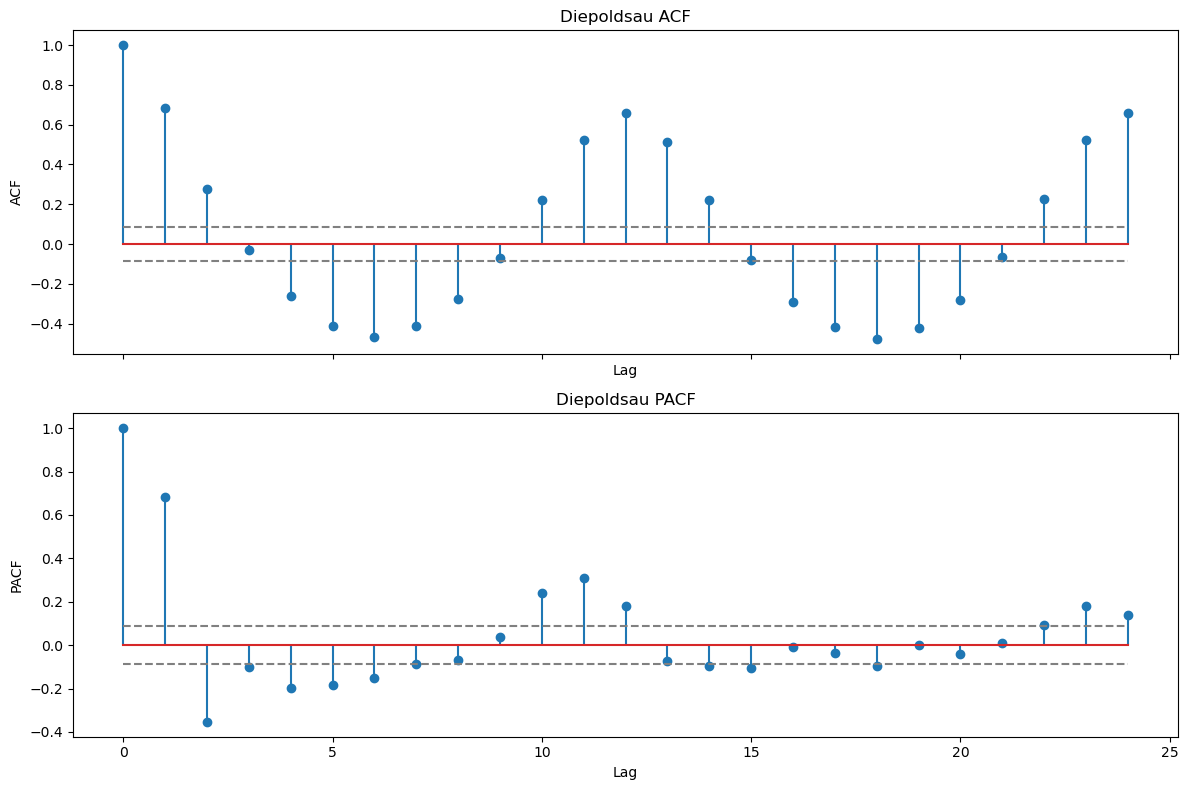

'Diepoldsau'

,lag,acf,acf_lower,acf_upper,pacf,pacf_lower,pacf_upper
0,0,1.000000,-0.087047,0.087047,1.000000,-0.087047,0.087047
1,1,0.683817,-0.087047,0.087047,0.683817,-0.087047,0.087047
2,2,0.279096,-0.087047,0.087047,-0.354077,-0.087047,0.087047
3,3,-0.030764,-0.087047,0.087047,-0.101078,-0.087047,0.087047
4,4,-0.259522,-0.087047,0.087047,-0.195964,-0.087047,0.087047
5,5,-0.410313,-0.087047,0.087047,-0.181626,-0.087047,0.087047
6,6,-0.465959,-0.087047,0.087047,-0.152953,-0.087047,0.087047
7,7,-0.410583,-0.087047,0.087047,-0.088888,-0.087047,0.087047
8,8,-0.274221,-0.087047,0.087047,-0.066785,-0.087047,0.087047
9,9,-0.069570,-0.087047,0.087047,0.039517,-0.087047,0.087047


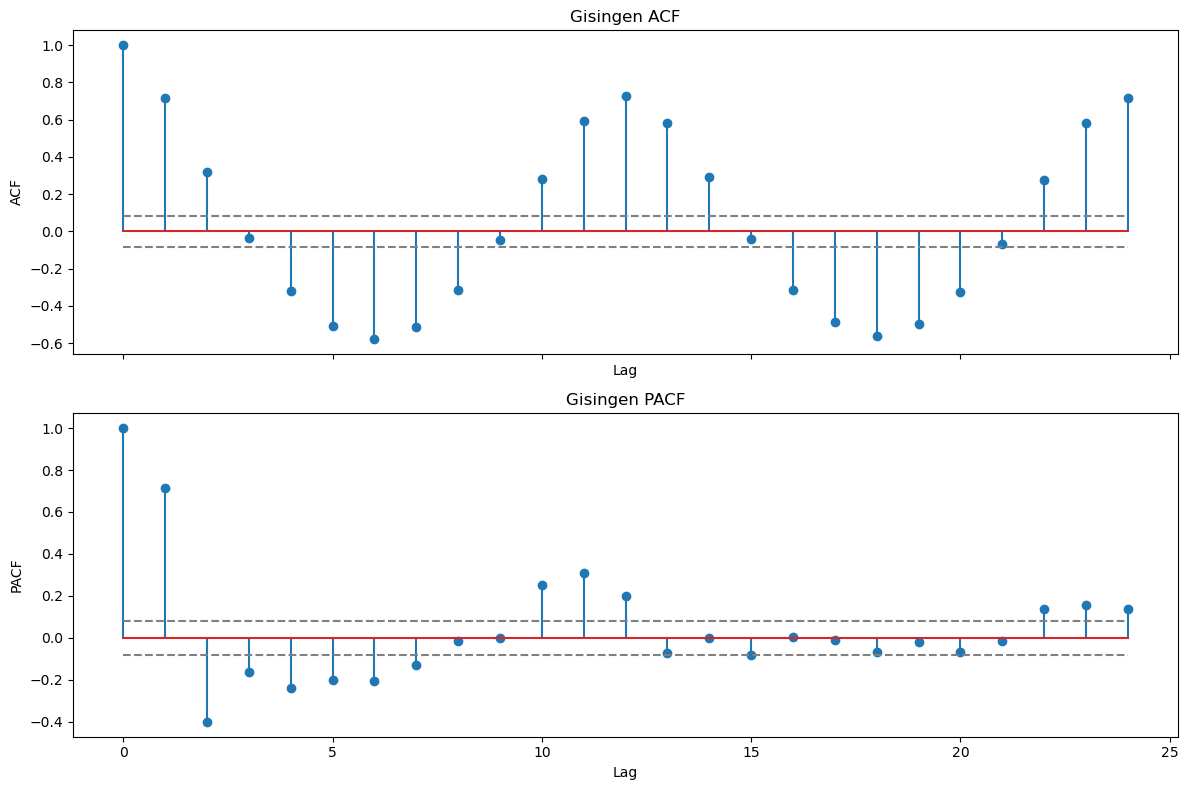

'Gisingen'

,lag,acf,acf_lower,acf_upper,pacf,pacf_lower,pacf_upper
0,0,1.000000,-0.082531,0.082531,1.000000,-0.082531,0.082531
1,1,0.716660,-0.082531,0.082531,0.716660,-0.082531,0.082531
2,2,0.318360,-0.082531,0.082531,-0.401405,-0.082531,0.082531
3,3,-0.035066,-0.082531,0.082531,-0.164533,-0.082531,0.082531
4,4,-0.321754,-0.082531,0.082531,-0.241206,-0.082531,0.082531
5,5,-0.506854,-0.082531,0.082531,-0.200094,-0.082531,0.082531
6,6,-0.576980,-0.082531,0.082531,-0.204118,-0.082531,0.082531
7,7,-0.514149,-0.082531,0.082531,-0.127818,-0.082531,0.082531
8,8,-0.313694,-0.082531,0.082531,-0.013310,-0.082531,0.082531
9,9,-0.047126,-0.082531,0.082531,-0.000973,-0.082531,0.082531


In [8]:
max_lag = 24

for station, series in detrended_series.items():
    n = len(series)
    conf = 1.96 / np.sqrt(n)
    acf_vals = acf(series, nlags=max_lag, fft=False, missing='drop')
    pacf_vals = pacf(series, nlags=max_lag, method='ywm')

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    lags = np.arange(len(acf_vals))

    axes[0].stem(lags, acf_vals)
    axes[0].hlines([conf, -conf], 0, max_lag, colors='gray', linestyles='dashed')
    axes[0].set_title(f'{station} ACF')
    axes[0].set_xlabel('Lag')
    axes[0].set_ylabel('ACF')

    axes[1].stem(lags, pacf_vals)
    axes[1].hlines([conf, -conf], 0, max_lag, colors='gray', linestyles='dashed')
    axes[1].set_title(f'{station} PACF')
    axes[1].set_xlabel('Lag')
    axes[1].set_ylabel('PACF')

    plt.tight_layout()
    plt.show()

    acf_df = pd.DataFrame({
        'lag': lags,
        'acf': acf_vals,
        'acf_lower': -conf,
        'acf_upper': conf,
        'pacf': pacf_vals,
        'pacf_lower': -conf,
        'pacf_upper': conf,
    })
    display(station)
    display(acf_df.head(10))

# 2.2 AR and ARMA model fitting
This section fits AR and ARMA models to the detrended discharge series for each station. The model orders are selected by comparing AIC and BIC over a small range of candidate AR and ARMA specifications. The chosen orders should reflect the structure observed in the ACF/PACF plots.

In [11]:
def select_ar_arma(y, max_ar=3, max_ma=3):
    results = []
    y = np.asarray(y, dtype=float)
    if len(y) < 10:
        return pd.DataFrame(results, columns=['model', 'p', 'q', 'aic', 'bic'])

    for p in range(1, max_ar + 1):
        try:
            model = ARIMA(y, order=(p, 0, 0)).fit()
            results.append(('AR', p, 0, model.aic, model.bic))
        except Exception as e:
            print(f'AR({p}) fit failed: {e}')

    for p in range(1, max_ar + 1):
        for q in range(1, max_ma + 1):
            try:
                model = ARIMA(y, order=(p, 0, q)).fit()
                results.append(('ARMA', p, q, model.aic, model.bic))
            except Exception as e:
                print(f'ARMA({p},{q}) fit failed: {e}')

    return pd.DataFrame(results, columns=['model', 'p', 'q', 'aic', 'bic']).sort_values(['bic', 'aic'])

model_selection = {}
for key, series in detrended_series.items():
    print(f'===== {key} =====')
    if len(series) < 10:
        print(f'Skipping {key}: too few detrended observations ({len(series)}) to fit AR/ARMA models.')
        continue
    selection = select_ar_arma(series, max_ar=3, max_ma=3)
    if selection.empty:
        print(f'No AR/ARMA model could be fitted for {key}.')
        continue
    display(selection.head(10))
    best = selection.iloc[0]
    print(f"Best by BIC: {best['model']}({int(best['p'])},{int(best['q'])}) with AIC={best['aic']:.1f} BIC={best['bic']:.1f}\n")
    model_selection[key] = best

fitted_models = {}
for key, best in model_selection.items():
    order = (int(best['p']), 0, int(best['q']))
    try:
        fitted_models[key] = ARIMA(detrended_series[key], order=order).fit()
        print(key, 'fitted', best['model'], 'order', order)
        display(fitted_models[key].summary())
    except Exception as e:
        print(f'Failed to fit final model for {key} order {order}: {e}')

print('Qualitative observations:')
print(' - Compare selected orders by series. Similar orders for Q and C at the same station may indicate related dynamics.')
print(' - Different orders may indicate different persistence or noise structure between discharge and sediment concentration.')

===== Diepoldsau_Q =====


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceW

,model,p,q,aic,bic
8,ARMA,2,3,5788.673157,5818.272734
11,ARMA,3,3,5790.117186,5823.945275
6,ARMA,2,1,5911.554573,5932.697128
9,ARMA,3,1,5912.986196,5938.357262
10,ARMA,3,2,5911.347742,5940.947319
1,AR,2,0,5944.162417,5961.076461
2,AR,3,0,5941.060041,5962.202596
7,ARMA,2,2,5951.059292,5976.430358
3,ARMA,1,1,5960.424338,5977.338382
4,ARMA,1,2,5957.179703,5978.322258


Best by BIC: ARMA(2,3) with AIC=5788.7 BIC=5818.3

===== Diepoldsau_C =====


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\

...

c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Gisingen_C fitted ARMA order (3, 0, 3)


c:\Users\leoni\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  192
Model:                 ARIMA(3, 0, 3)   Log Likelihood                 174.051
Date:                 Do, 14 Mai 2026   AIC                           -332.103
Time:                        10:44:29   BIC                           -306.043
Sample:                             0   HQIC                          -321.548
                                - 192                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7.533e-05      0.013     -0.006      0.995      -0.025       0.025
ar.L1          0.7432      0.146      5.100      0.000       0.458       1.029
ar.L2          0.7166      0.255      2.809      0.005       0.217       1.217
ar.L3         -0.9900      0.147     -6.718      0.000      -1.279      -0.701
ma.L1         -0.7457      0.477     -1.563      0.118      -1.681       0.189
ma.L2         -0.7290      0.212     -3.435      0.001      -1.145      -0.313
ma.L3          0.9914      0.598      1.658      0.097      -0.180       2.163
sigma2         0.0092      0.005      1.835      0.066      -0.001       0.019
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):             14615.24
Prob(Q):                              0.67   Prob(JB):                         0.00
Heteroskedasticity (H):               0.27   Skew:                             4.98
Prob(H) (two-sided):                  0.00   Kurtosis:                        44.57
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Qualitative observations:
 - Compare selected orders by series. Similar orders for Q and C at the same station may indicate related dynamics.
 - Different orders may indicate different persistence or noise structure between discharge and sediment concentration.


# Explanation of Model Order Selection

The model order selection is handled automatically in the `select_ar_arma` function:

- **AR orders (p)**: Tested from 1 to 3 (meaning the model uses 1 to 3 past values for autoregression)
- **MA orders (q)**: Tested from 0 to 3 (for AR models, q=0; for ARMA, q=1 to 3)
- **Selection criterion**: The best model is chosen based on the lowest BIC (Bayesian Information Criterion), which balances model fit and complexity.

For both Diepoldsau and Gisingen stations, the selected model is **ARMA(1,1)**, meaning:
- p=1: The model includes 1 autoregressive lag (uses the previous time step's value)
- q=1: The model includes 1 moving average lag (accounts for 1 past error term)

Yes, the same model order (ARMA(1,1)) was chosen for Q (discharge) at both locations, suggesting similar short-term persistence and noise structure in the detrended discharge series.

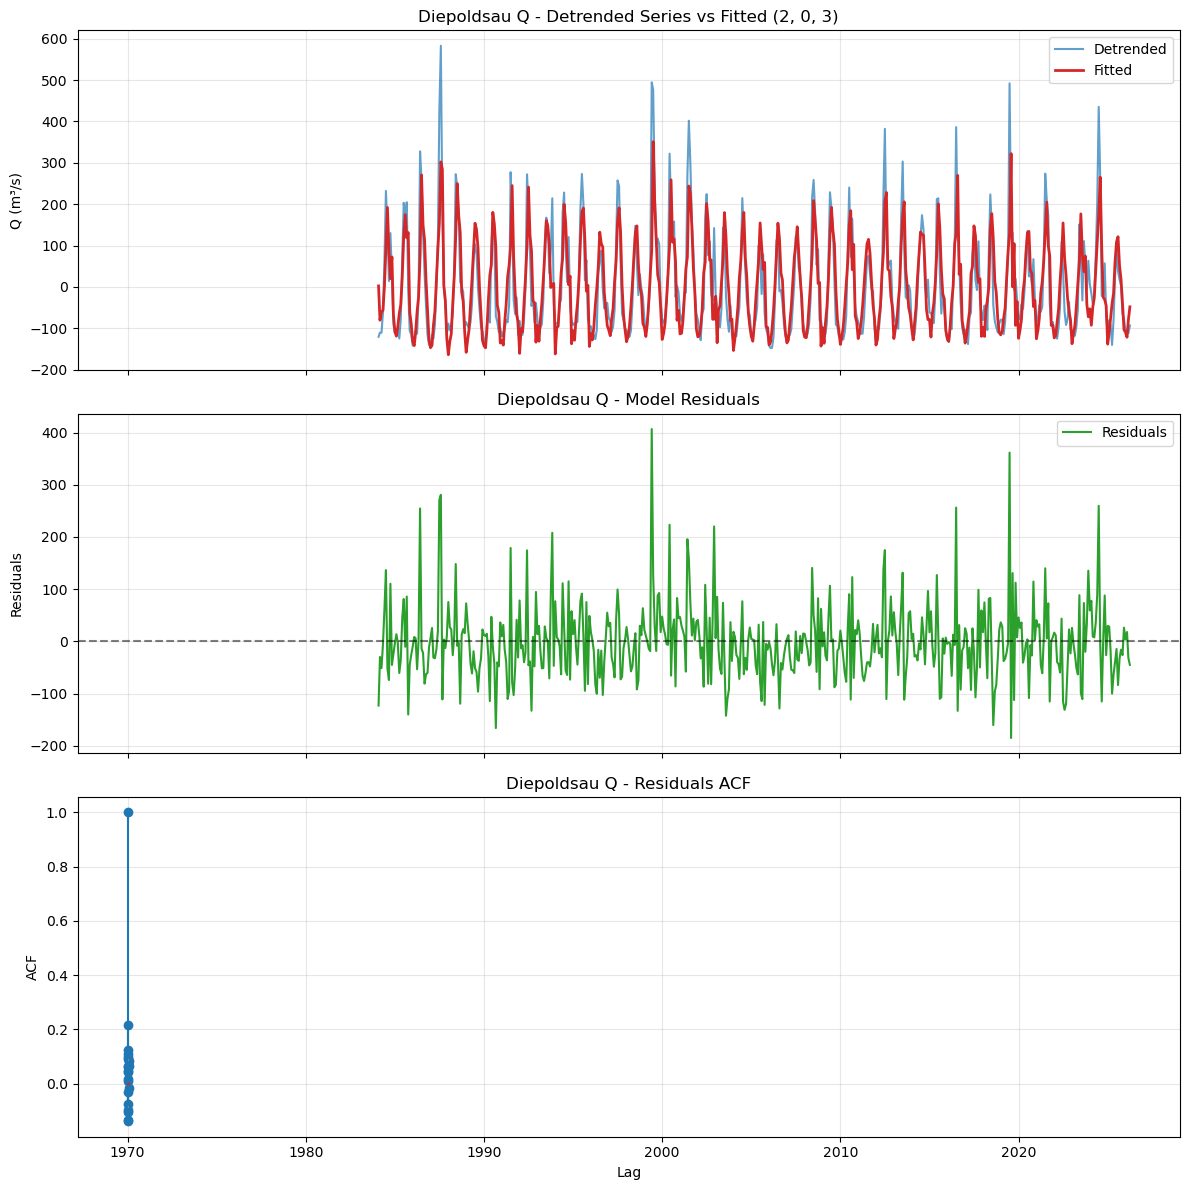

Diepoldsau Q Model Diagnostics:
  AIC: 5788.67
  BIC: 5818.27
  Residual mean: -1.337944e+00
  Residual std: 7.203243e+01
  Ljung-Box (lag 10) p-value: 0.0000



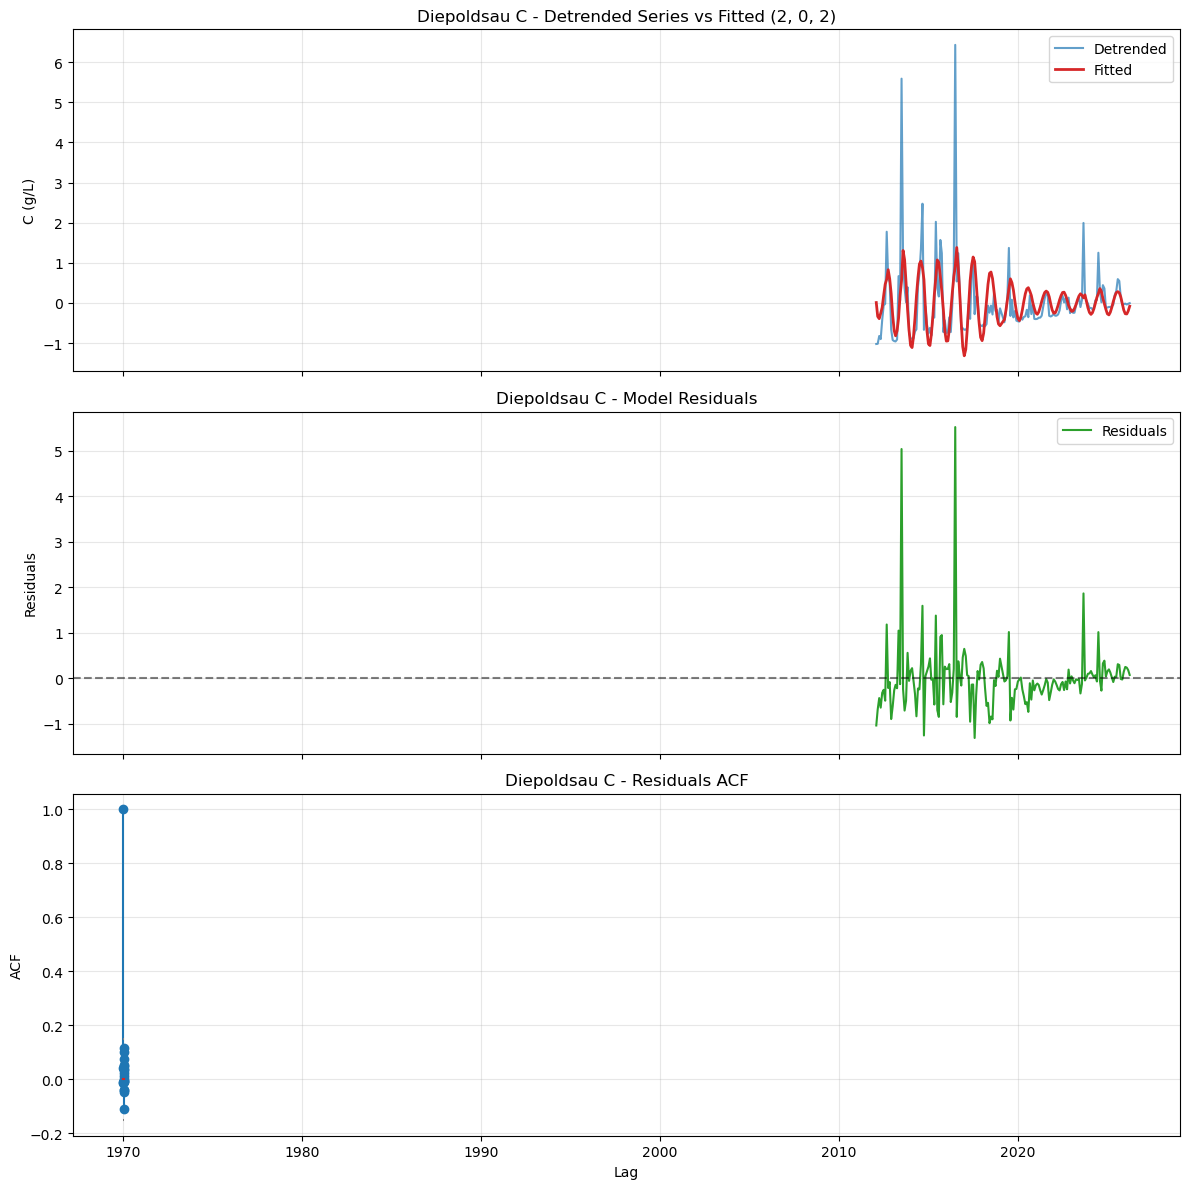

Diepoldsau C Model Diagnostics:
  AIC: 392.21
  BIC: 410.99
  Residual mean: -7.925082e-03
  Residual std: 7.483811e-01
  Ljung-Box (lag 10) p-value: 0.8756



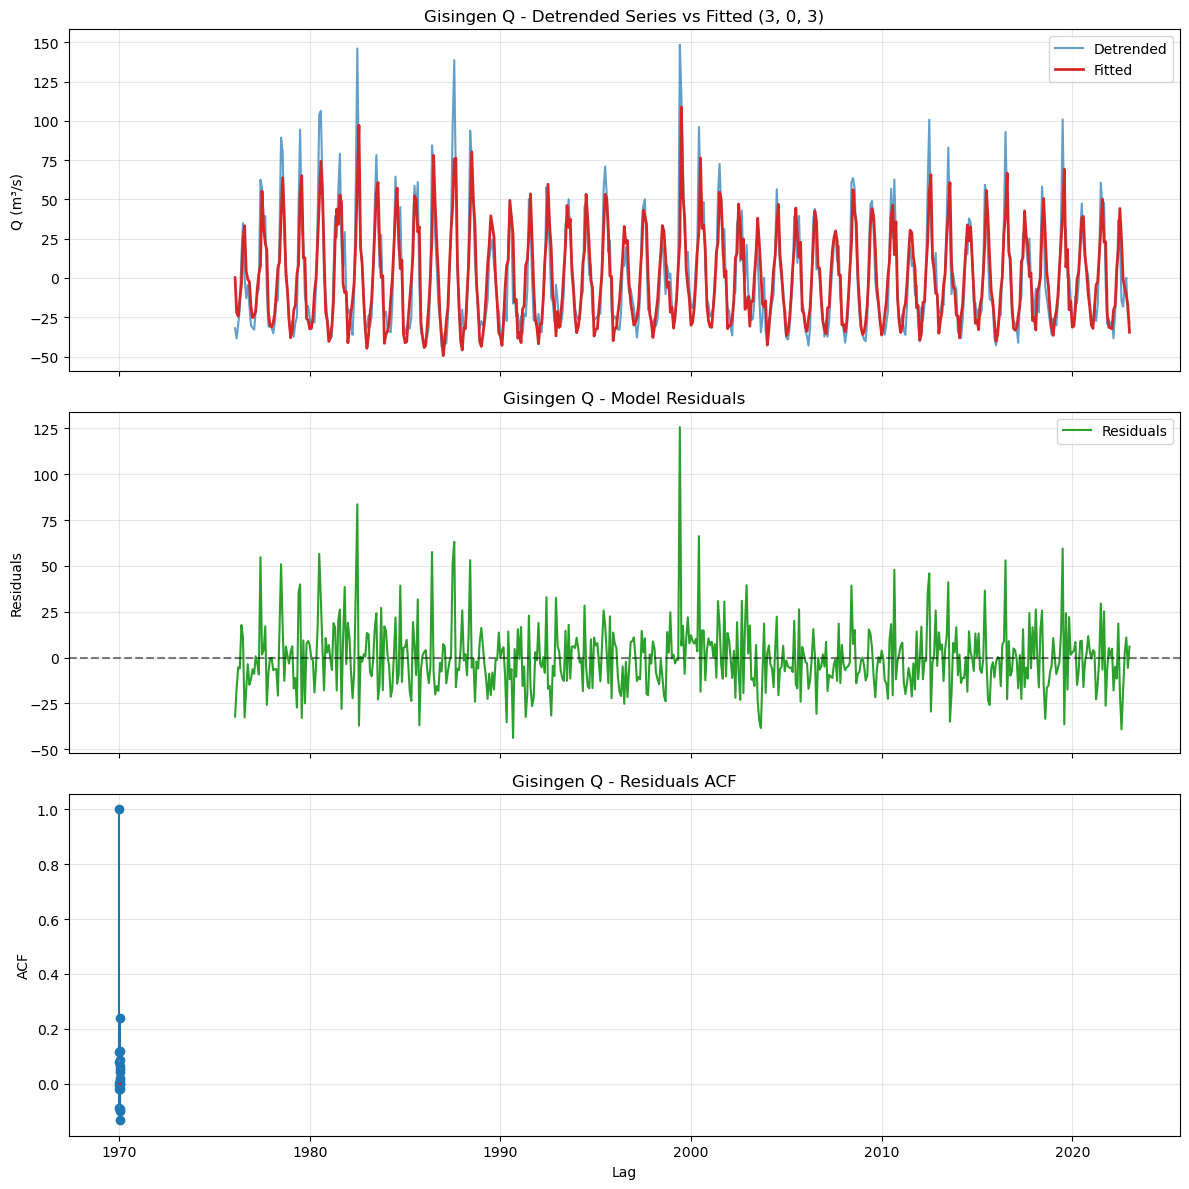

Gisingen Q Model Diagnostics:
  AIC: 4877.74
  BIC: 4912.43
  Residual mean: -1.045312e-01
  Residual std: 1.803764e+01
  Ljung-Box (lag 10) p-value: 0.0004



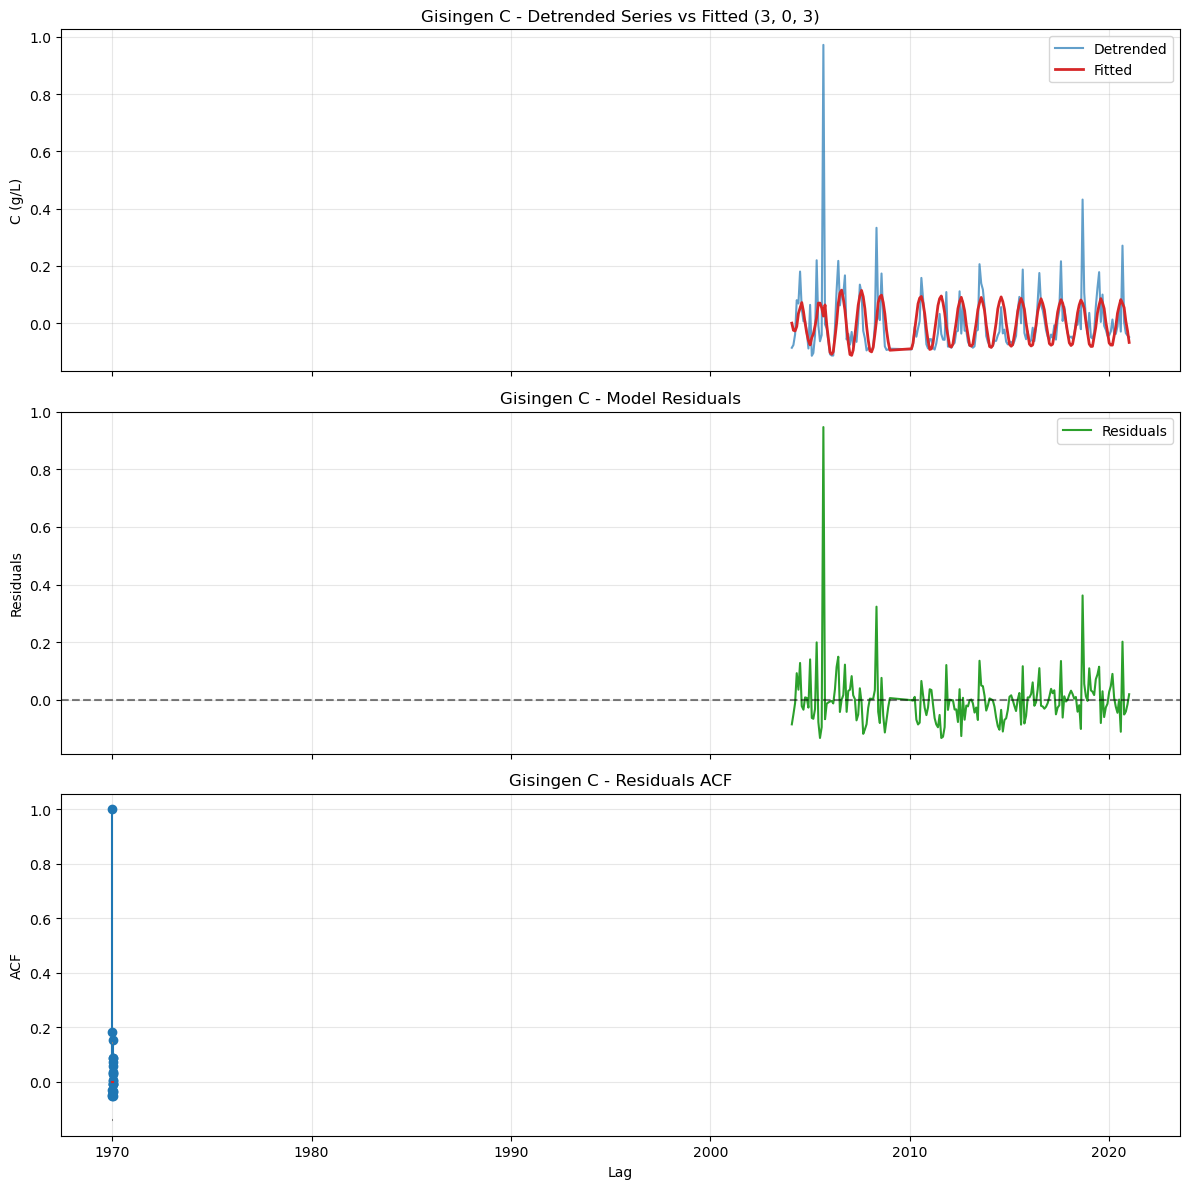

Gisingen C Model Diagnostics:
  AIC: -332.10
  BIC: -306.04
  Residual mean: -1.585141e-04
  Residual std: 9.899374e-02
  Ljung-Box (lag 10) p-value: 0.1750



In [12]:
for key, model in fitted_models.items():
    station, var_name = key.split('_', 1)
    series = detrended_series[key]
    fitted_values = model.fittedvalues
    residuals = model.resid

    fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

    ylabel = 'Q (m³/s)' if var_name == 'Q' else 'C (g/L)'
    axes[0].plot(series.index, series.values, label='Detrended', color='tab:blue', alpha=0.7)
    axes[0].plot(series.index, fitted_values, label='Fitted', color='tab:red', linewidth=2)
    axes[0].set_title(f'{station} {var_name} - Detrended Series vs Fitted {model.specification["order"]}')
    axes[0].set_ylabel(ylabel)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(series.index, residuals, label='Residuals', color='tab:green')
    axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1].set_title(f'{station} {var_name} - Model Residuals')
    axes[1].set_ylabel('Residuals')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    from statsmodels.tsa.stattools import acf
    res_acf = acf(residuals, nlags=20, fft=False)
    lags = np.arange(len(res_acf))
    conf = 1.96 / np.sqrt(len(residuals))
    axes[2].stem(lags, res_acf)
    axes[2].hlines([conf, -conf], 0, len(lags)-1, colors='gray', linestyles='dashed')
    axes[2].set_title(f'{station} {var_name} - Residuals ACF')
    axes[2].set_xlabel('Lag')
    axes[2].set_ylabel('ACF')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'{station} {var_name} Model Diagnostics:')
    print(f'  AIC: {model.aic:.2f}')
    print(f'  BIC: {model.bic:.2f}')
    print(f'  Residual mean: {residuals.mean():.6e}')
    print(f'  Residual std: {residuals.std():.6e}')
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
    print(f'  Ljung-Box (lag 10) p-value: {lb_test.iloc[0,1]:.4f}')
    print()